# The exchange economy

**Table of contents**<a id='toc0_'></a>    
- 1. [The model](#toc1_)    
- 2. [Setup](#toc2_)    
- 3. [The model as a class](#toc3_)    
- 4. [The equilibrium price](#toc4_)    
  - 4.1. [Excess demand](#toc4_1_)    
  - 4.2. [By hand](#toc4_2_)    
  - 4.3. [With a root-finder](#toc4_3_)    
  - 4.4. [Testing the code](#toc4_4_)    
- 5. [The Edgeworth box](#toc5_)    
  - 5.1. [Drawing the box](#toc5_1_)    
  - 5.2. [Indifference curves](#toc5_2_)    
  - 5.3. [The equilibrium in the box](#toc5_3_)    
- 6. [An auction algorithm](#toc6_)    
  - 6.1. [Tâtonnement](#toc6_1_)    
  - 6.2. [When it fails](#toc6_2_)    
- 7. [Many economies](#toc7_)    
  - 7.1. [Random endowments](#toc7_1_)    
  - 7.2. [The contract curve](#toc7_2_)    
- 8. [Summary](#toc8_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In the last lecture we took a model of a *whole economy over time* from equations to figures. This time we do the same with a model of a **market**: two people who own some goods and are allowed to trade with each other.

**The focus is programming, not economic theory.** The model is used because it is small enough to fit on one page, and because it lets us practice:

1. Writing the model as a **class** (lecture 3).
2. Solving it **by hand** and with a **root-finder**, and checking that the two agree (lecture 5).
3. Writing our own **iterative algorithm** with a `for` loop - and seeing it fail.
4. **Testing** the code with `assert` (lecture 9).
5. Making a **figure that is not a standard plot** (lecture 4).
6. Solving **many** economies with **random** starting points (lecture 6).

You do *not* need to know any of the economics in advance. Everything you need is on the next page.

## 1. <a id='toc1_'></a>[The model](#toc0_)

**Two people and two goods.** The two people are called $A$ and $B$. The two goods are called good 1 and good 2 - think of them as *apples* and *bananas*.

**Endowments.** Nobody produces anything. The goods are simply there already, and each person **owns** some of them from the start. This is called the *endowment*:

* $\omega_1^A$ and $\omega_2^A$: what $A$ owns of good 1 and good 2
* $\omega_1^B$ and $\omega_2^B$: what $B$ owns

We measure the goods so that there is **exactly one unit of each good in total**. Whatever $A$ does not own, $B$ owns:

$$ \omega_1^B = 1-\omega_1^A, \qquad \omega_2^B = 1-\omega_2^A $$

**Consumption.** After trading, $A$ ends up with $x_1^A$ of good 1 and $x_2^A$ of good 2, and $B$ with $x_1^B$ and $x_2^B$. Nothing is created or destroyed, so what they end up with must still add up to one of each good.

**Preferences.** How much a person likes a basket of goods is measured by a **utility function**. A higher number means a more attractive basket. We use

$$ u^A(x_1,x_2) = x_1^{\alpha}x_2^{1-\alpha}, \qquad u^B(x_1,x_2) = x_1^{\beta}x_2^{1-\beta}, \qquad \alpha,\beta \in (0,1) $$

The only thing you need to read out of these formulas is:

* both people want **more** of both goods,
* $\alpha$ says how much $A$ cares about good 1 relative to good 2, and $\beta$ says the same for $B$,
* if $\alpha \neq \beta$ the two people have **different tastes**

**Prices.** Trade happens at a price. Let $p_1$ be the price of good 1 and $p_2$ the price of good 2. Only the **relative** price matters - doubling both prices changes nothing, because everybody both buys and sells. So we are free to fix

$$ p_2 = 1 $$

and measure everything in units of good 2. Then $p_1$ is the *only* unknown in the whole model. This choice is called a **numeraire**.

**Income.** At the price $p_1$, what $A$ owns is worth

$$ m^A = p_1\omega_1^A + \omega_2^A $$

and this is what she has to spend. Similarly for $B$.

**Demand.** Each person buys the basket she likes best among those she can afford. For the utility functions above the answer has a very simple form: **spend the share $\alpha$ of your income on good 1 and the rest on good 2**. Dividing by the prices to get quantities,

$$
\begin{aligned}
x_1^{A}(p_1) &= \alpha\frac{m^A}{p_1}, &\qquad x_2^{A}(p_1) &= (1-\alpha)\,m^A \\
x_1^{B}(p_1) &= \beta\frac{m^B}{p_1}, &\qquad x_2^{B}(p_1) &= (1-\beta)\,m^B
\end{aligned}
$$

(This can be derived with pen and paper by maximizing $u$ subject to the budget - we just take the result as given here.)

Note the two forces in $x_1^A(p_1)$: a higher $p_1$ makes good 1 more **expensive** (the $p_1$ in the denominator), but it also makes $A$ **richer** if she owns a lot of good 1 (the $p_1$ inside $m^A$).

**Equilibrium.** A price is an **equilibrium price** when the plans of the two people fit together: they together want to consume exactly what exists. Define **excess demand** as *wanted minus available*,

$$
\begin{aligned}
\varepsilon_1(p_1) &= x_1^{A}(p_1) + x_1^{B}(p_1) - 1 \\
\varepsilon_2(p_1) &= x_2^{A}(p_1) + x_2^{B}(p_1) - 1
\end{aligned}
$$

The **equilibrium price** $p_1^{\ast}$ is the price where excess demand is zero. This is called a **Walras equilibrium**.

**One equation is enough.** Everybody spends exactly her income, so the *value* of what is demanded always equals the *value* of what is owned, at any price:

$$ p_1\varepsilon_1(p_1) + \varepsilon_2(p_1) = 0 \qquad \text{for all } p_1 $$

This is **Walras' law**. It means that if market 1 clears then market 2 clears automatically. So we only have to solve **one equation in one unknown** - and we get a free test of our code.

**Solving by hand.** Insert the demand functions in $\varepsilon_1(p_1) = 0$ and multiply by $p_1$:

$$ \alpha(p_1\omega_1^A+\omega_2^A) + \beta(p_1\omega_1^B+\omega_2^B) = p_1 $$

Collecting the terms with $p_1$ on one side and using $\omega_1^A+\omega_1^B=1$ gives

$$ \boxed{\;p_1^{\ast} = \frac{\alpha\omega_2^A + \beta\omega_2^B}{(1-\alpha)\omega_1^A + (1-\beta)\omega_1^B}\;} $$

As in the Solow lecture: having an answer we can compute by hand is *very* useful - we will use it to test everything else.

## 2. <a id='toc2_'></a>[Setup](#toc0_)

We import the packages we need and set the plotting options used in all lectures.

In [1]:
%load_ext autoreload
%autoreload 2

from types import SimpleNamespace
import numpy as np
from scipy import optimize

import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'-'})
plt.rcParams.update({'font.size':14})

# the default colors of matplotlib (nice to have when we want to control colors by hand)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

## 3. <a id='toc3_'></a>[The model as a class](#toc0_)

We write the model as a **class**:

* the **parameters** ($\alpha$, $\beta$, $\omega^A$) and the settings of the algorithms are **attributes** set in `__init__`
* the **equations** of the model (utility, demand, excess demand) are **methods**
* the **solvers** are methods, and the solution is collected in `self.sol`

The class lives in its own file, **[exchange.py](exchange.py)** - open it and read along.

In [2]:
from exchange import ExchangeEconomy # the model class, see exchange.py

The class has one method per equation and one per solver:

| | |
| --- | --- |
| `utility_A(x1,x2)`, `utility_B(x1,x2)` | the two utility functions |
| `demand_A(p1)`, `demand_B(p1)` | the two demand functions, each returns $(x_1,x_2)$ |
| `excess_demand(p1)` | wanted minus available, returns $(\varepsilon_1,\varepsilon_2)$ |
| `equilibrium_price()` | the analytical equilibrium price |
| `solve_equilibrium_price()` | the same, found with a root-finder |
| `solve(p1)` | the price, the allocation and the utilities, collected in `self.sol` |
| `tatonnement(p1_guess,nu)` | the auction algorithm of section 6 |

**Note on `sol`:** as in the Solow model the results are collected in a `SimpleNamespace` rather than in a lot of loose attributes. Then `sol.p1`, `sol.x1A`, ... clearly belong together and can be handed around as one object.

We create an economy and print it (this calls `__str__`):

In [3]:
model = ExchangeEconomy()
print(model)

Exchange economy with:
  alpha = 0.33 (A spends this share of her income on good 1)
  beta  = 0.67 (B spends this share of her income on good 1)
  wA    = (0.80,0.30) (what A owns)
  wB    = (0.20,0.70) (what B owns)


Read the numbers as a story: $A$ owns most of good 1 ($\omega_1^A = 0.80$) but spends only a third of her income on it ($\alpha = 1/3$). $B$ is the other way around. They should have something to trade about.

A new economy with other parameters is created by passing keyword arguments, exactly as for the Solow model:

In [4]:
model_equal = ExchangeEconomy(alpha=0.50,beta=0.50) # only the preferences are changed
print(model_equal)

Exchange economy with:
  alpha = 0.50 (A spends this share of her income on good 1)
  beta  = 0.50 (B spends this share of her income on good 1)
  wA    = (0.80,0.30) (what A owns)
  wB    = (0.20,0.70) (what B owns)


## 4. <a id='toc4_'></a>[The equilibrium price](#toc0_)

### 4.1. <a id='toc4_1_'></a>[Excess demand](#toc0_)

Before solving anything, let us **look** at the equation we are about to solve. We evaluate excess demand on a grid of prices.

Because `demand_A` and `demand_B` only use arithmetic, we can hand them the whole grid at once instead of looping over it.

In [5]:
# a. a grid of prices
p1_grid = np.linspace(0.2,3.0,500)

# b. excess demand at every price on the grid, in one go
eps1_grid,eps2_grid = model.excess_demand(p1_grid)

# c. a few of them
for p1 in [0.25,0.50,1.00,2.00,3.00]:
    eps1,eps2 = model.excess_demand(p1)
    print(f'p1 = {p1:.2f}: excess demand of good 1 = {eps1:7.4f}, of good 2 = {eps2:7.4f}')

p1 = 0.25: excess demand of good 1 =  1.6667, of good 2 = -0.4167
p1 = 0.50: excess demand of good 1 =  0.5333, of good 2 = -0.2667
p1 = 1.00: excess demand of good 1 = -0.0333, of good 2 =  0.0333
p1 = 2.00: excess demand of good 1 = -0.3167, of good 2 =  0.6333
p1 = 3.00: excess demand of good 1 = -0.4111, of good 2 =  1.2333


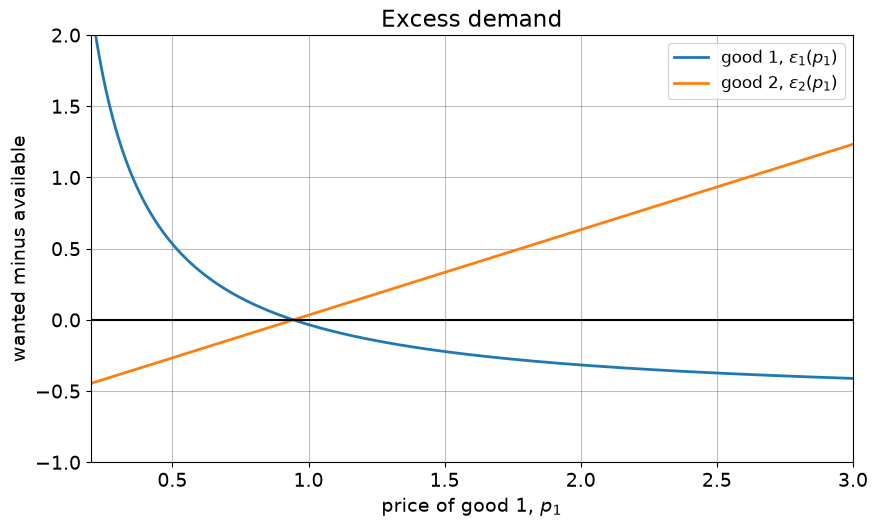

In [6]:
fig = plt.figure(figsize=(9,5.5))
ax = fig.add_subplot(1,1,1)

ax.plot(p1_grid,eps1_grid,lw=2,color=colors[0],label=r'good 1, $\varepsilon_1(p_1)$')
ax.plot(p1_grid,eps2_grid,lw=2,color=colors[1],label=r'good 2, $\varepsilon_2(p_1)$')
ax.axhline(0,lw=1.5,color='black')

ax.set_title('Excess demand')
ax.set_xlabel('price of good 1, $p_1$')
ax.set_ylabel('wanted minus available')
ax.set_xlim(p1_grid[0],p1_grid[-1])
ax.set_ylim(-1,2)
ax.legend(loc='upper right',fontsize=12)

fig.tight_layout()

**Reading the figure.** Good 1 is in excess demand at low prices and in excess supply at high prices, and the two curves cross zero at the *same* price - that is Walras' law. The curve for good 1 is **downward sloping and crosses zero once**, so there is exactly one equilibrium price, and a root-finder will have an easy time.

### 4.2. <a id='toc4_2_'></a>[By hand](#toc0_)

The method `equilibrium_price()` implements the formula we derived by hand:

In [7]:
p1_star = model.equilibrium_price()
print(f'p1* = {p1_star:.6f}')

eps1,eps2 = model.excess_demand(p1_star)
print(f'excess demand at this price: {eps1:.2e} and {eps2:.2e}')

p1* = 0.944444
excess demand at this price: 2.22e-16 and 2.22e-16


`solve()` stores the price *and* the resulting allocation:

In [8]:
sol = model.solve()

print(f'p1* = {sol.p1:.4f}')
print(f'A consumes ({sol.x1A:.4f},{sol.x2A:.4f}) and had ({model.w1A:.2f},{model.w2A:.2f})')
print(f'B consumes ({sol.x1B:.4f},{sol.x2B:.4f}) and had ({1-model.w1A:.2f},{1-model.w2A:.2f})')
print('')
print(f'A sells {model.w1A-sol.x1A:.4f} of good 1 and buys {sol.x2A-model.w2A:.4f} of good 2')

p1* = 0.9444
A consumes (0.3725,0.7037) and had (0.80,0.30)
B consumes (0.6275,0.2963) and had (0.20,0.70)

A sells 0.4275 of good 1 and buys 0.4037 of good 2


**Task:** What is the equilibrium price if the two people have **exactly the same** preferences, $\alpha = \beta$? Use `model_equal` from section 3, and compare with $\alpha/(1-\alpha)$.

In [9]:
# write your code here

In [10]:
# answer
p1_equal = model_equal.equilibrium_price()

print(f'p1* = {p1_equal:.6f}')
print(f'alpha/(1-alpha) = {model_equal.alpha/(1-model_equal.alpha):.6f}')

p1* = 1.000000
alpha/(1-alpha) = 1.000000


With identical preferences the endowments drop out of the formula completely: the price only reflects how much the two goods are *wanted*, not who happens to own them.

### 4.3. <a id='toc4_3_'></a>[With a root-finder](#toc0_)

In a lot of interesting models there is **no formula** for the equilibrium price. Then we solve

$$ \varepsilon_1(p_1) = 0 $$

numerically with a root-finder (lecture 5). This is what `solve_equilibrium_price()` does with `optimize.root_scalar`. The bracket `[0.01,100]` is safe here because we saw in section 4.1 that excess demand changes sign inside it.

In [11]:
p1_num = model.solve_equilibrium_price()

print(f'p1* (by hand)     = {p1_star:.10f}')
print(f'p1* (root-finder) = {p1_num:.10f}')
print(f'the two agree: {np.isclose(p1_star,p1_num)}')

p1* (by hand)     = 0.9444444444
p1* (root-finder) = 0.9444444444
the two agree: True


**Good habit:** when you *can* solve a problem by hand, always use it to test your numerical code. In the problem set you extend the model to cases where the formula gets harder - and then you will already trust the machinery.

### 4.4. <a id='toc4_4_'></a>[Testing the code](#toc0_)

Before we start *using* the model we should convince ourselves that it does what we think it does. As in lecture 9 we write a handful of **`assert` statements**, and the art is to find cases where we already know the answer:

1. **Walras' law** must hold at *every* price: $p_1\varepsilon_1 + \varepsilon_2 = 0$.
2. **Nothing disappears:** in equilibrium the two people together consume exactly one unit of each good.
3. **No trade when there is nothing to gain:** if the two have the same preferences *and* $A$ owns the same share $\theta$ of both goods, then there is no reason to trade, and everybody must end up consuming exactly what they started with.

In [12]:
# test 1: Walras' law holds at every price
eps1,eps2 = model.excess_demand(p1_grid)
assert np.allclose(p1_grid*eps1+eps2,0.0), "Walras' law is violated"

# test 2: in equilibrium the allocation adds up to the total endowment
sol = model.solve()
assert np.isclose(sol.x1A+sol.x1B,1.0), 'good 1 does not add up'
assert np.isclose(sol.x2A+sol.x2B,1.0), 'good 2 does not add up'

# test 3: no trade when there is nothing to gain
for theta in [0.2,0.5,0.9]:
    model_notrade = ExchangeEconomy(alpha=0.40,beta=0.40,w1A=theta,w2A=theta)
    sol_notrade = model_notrade.solve()
    assert np.isclose(sol_notrade.x1A,theta), f'A trades good 1 although she should not (theta = {theta})'
    assert np.isclose(sol_notrade.x2A,theta), f'A trades good 2 although she should not (theta = {theta})'

print('all tests passed')

all tests passed


**No news is good news:** if the cell runs without complaining, all three tests passed.

Test 1 is the most valuable one. It uses **no numbers at all** - only a property the model must have - and it is checked at 500 different prices at once. Such tests catch typos that a single hand-computed number never would.

**Task:** Add a fourth test: at *any* price each person spends exactly her income, $p_1x_1 + x_2 = p_1\omega_1 + \omega_2$. Check it for both $A$ and $B$ on the whole price grid.

In [13]:
# write your code here

In [14]:
# answer
x1A,x2A = model.demand_A(p1_grid)
x1B,x2B = model.demand_B(p1_grid)

spent_A = p1_grid*x1A + x2A
income_A = p1_grid*model.w1A + model.w2A
assert np.allclose(spent_A,income_A), 'A does not spend exactly her income'

spent_B = p1_grid*x1B + x2B
income_B = p1_grid*(1-model.w1A) + (1-model.w2A)
assert np.allclose(spent_B,income_B), 'B does not spend exactly her income'

print('test passed')

test passed


Notice that test 1 follows from this one: if both people spend exactly their income at every price, then the total value of what is demanded equals the total value of what is owned - which is precisely $p_1\varepsilon_1+\varepsilon_2=0$.

## 5. <a id='toc5_'></a>[The Edgeworth box](#toc0_)

### 5.1. <a id='toc5_1_'></a>[Drawing the box](#toc0_)

Everything in this model happens inside a **unit square**, and there is a classic trick for drawing it - the **Edgeworth box**:

* A point in the square is $A$'s consumption $(x_1^A,x_2^A)$, read from the **lower left** corner.
* Because the two goods add up to one, the *same* point is also $B$'s consumption $(1-x_1^A,1-x_2^A)$, read from the **upper right** corner.

So one point in the square describes the *whole* economy: who gets what. The lower left corner means "$A$ gets nothing", the upper right corner means "$B$ gets nothing".

This is a figure `matplotlib` has no ready-made function for, so we build it ourselves. `edgeworth_box()` in [edgeworth_box.py](edgeworth_box.py) draws an **empty** box and hands back `fig` and `ax` - it knows nothing about the model, so every figure below is just three more lines. The trick for $B$'s axes is `secondary_xaxis`, which draws an extra axis on top of the existing one with values computed by a function - here $x \mapsto 1-x$.

In [15]:
from edgeworth_box import edgeworth_box # see edgeworth_box.py

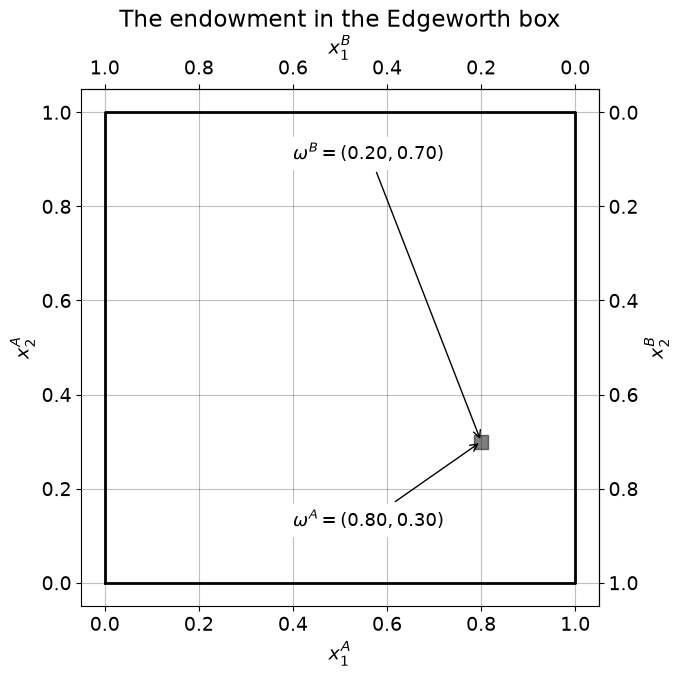

In [16]:
fig,ax = edgeworth_box()

ax.plot(model.w1A,model.w2A,'s',ms=10,color='black',alpha=0.5,zorder=3,label='endowment')

ax.annotate(r'$\omega^A=(0.80,0.30)$',xy=(model.w1A,model.w2A),xytext=(0.40,0.12),
            arrowprops=dict(arrowstyle='->'),fontsize=13,backgroundcolor='white')
ax.annotate(r"$\omega^B=(0.20,0.70)$",xy=(model.w1A,model.w2A),xytext=(0.40,0.90),
            arrowprops=dict(arrowstyle='->'),fontsize=13,backgroundcolor='white')

ax.set_title('The endowment in the Edgeworth box')
fig.tight_layout()

**Read the black square in two ways.** Measured from the lower left corner it says that $A$ owns $0.80$ of good 1 and $0.30$ of good 2. Measured from the upper right corner - using the axes at the top and on the right - the *same* square says that $B$ owns $0.20$ and $0.70$.

### 5.2. <a id='toc5_2_'></a>[Indifference curves](#toc0_)

An **indifference curve** collects the baskets that give a person the same utility. For $A$ we solve $u^A = x_1^{\alpha}x_2^{1-\alpha}$ for $x_2$,

$$ x_2^A = \left(\frac{u^A}{(x_1^A)^{\alpha}}\right)^{\frac{1}{1-\alpha}} $$

and the same for $B$ with $\beta$. $B$'s curve then has to be **flipped** into $A$'s coordinates with $x^A = 1 - x^B$, so that both fit in the same box.

Curves further from *your own* corner are better for you. The two plotting functions are in [edgeworth_box.py](edgeworth_box.py) next to the box itself.

In [ ]:
from edgeworth_box import plot_indifference_A, plot_indifference_B # see edgeworth_box.py
from edgeworth_box import plot_improvement_set 

Both curves through the **endowment** show what the two people already have. Between them lies a lens-shaped region where **both** are better off than at the endowment - and that region is where trade will take us.

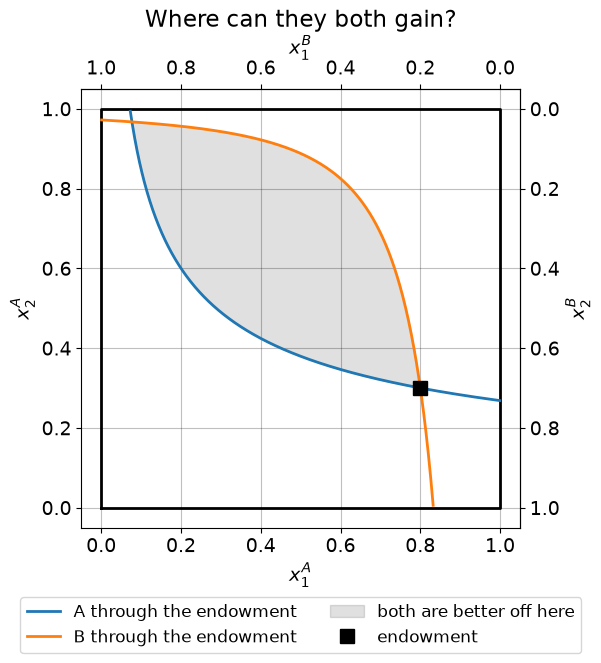

In [ ]:
fig,ax = edgeworth_box()

# a. the two indifference curves through the endowment
plot_indifference_A(ax,model,model.w1A,model.w2A,lw=2,color=colors[0],label='A through the endowment')
plot_indifference_B(ax,model,1-model.w1A,1-model.w2A,lw=2,color=colors[1],label='B through the endowment')

# b. the lens between them
plot_improvement_set(ax,model,model.w1A,model.w2A,color='black',alpha=0.12,label='both are better off here')

# c. the endowment
ax.plot(model.w1A,model.w2A,'s',ms=10,color='black',zorder=3,label='endowment')

ax.set_title('Where can they both gain?')
ax.legend(loc='upper center',bbox_to_anchor=(0.5,-0.14),ncol=2,fontsize=12)
fig.tight_layout()

### 5.3. <a id='toc5_3_'></a>[The equilibrium in the box](#toc0_)

At the price $p_1$ the two people can move away from the endowment along a **budget line**: selling one unit of good 1 buys $p_1$ units of good 2. Through the endowment the line is

$$ x_2^A = \omega_2^A - p_1\left(x_1^A-\omega_1^A\right) $$

and it is the *same* line for both of them - what $A$ sells, $B$ buys.

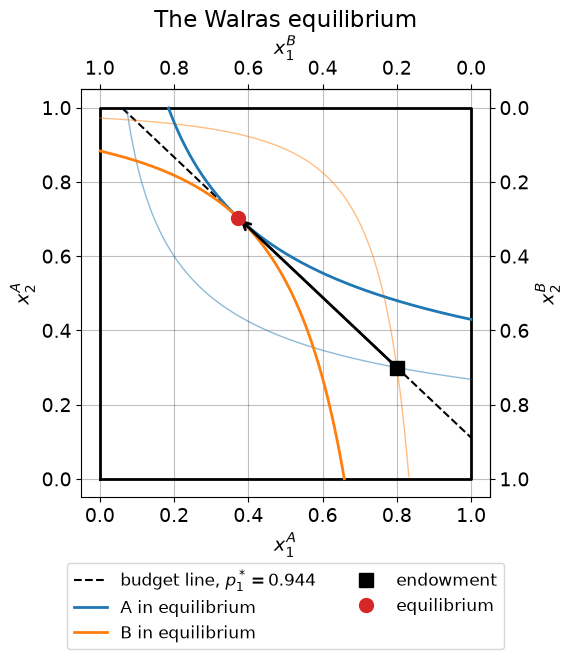

In [19]:
sol = model.solve()

fig,ax = edgeworth_box()

# a. the budget line through the endowment with slope -p1
x1_line = np.linspace(0,1,100)
x2_line = model.w2A - sol.p1*(x1_line-model.w1A)

I = (x2_line >= 0) & (x2_line <= 1)
ax.plot(x1_line[I],x2_line[I],lw=1.5,ls='--',color='black',label=f'budget line, $p_1^*={sol.p1:.3f}$')

# b. indifference curves through the endowment (thin) and the equilibrium (thick)
plot_indifference_A(ax,model,model.w1A,model.w2A,lw=1,alpha=0.5,color=colors[0])
plot_indifference_B(ax,model,1-model.w1A,1-model.w2A,lw=1,alpha=0.5,color=colors[1])
plot_indifference_A(ax,model,sol.x1A,sol.x2A,lw=2,color=colors[0],label='A in equilibrium')
plot_indifference_B(ax,model,sol.x1B,sol.x2B,lw=2,color=colors[1],label='B in equilibrium')

# c. the two points and the trade between them
ax.annotate('',xy=(sol.x1A,sol.x2A),xytext=(model.w1A,model.w2A),
            arrowprops=dict(arrowstyle='->',lw=2,color='black'))
ax.plot(model.w1A,model.w2A,'s',ms=10,color='black',zorder=3,label='endowment')
ax.plot(sol.x1A,sol.x2A,'o',ms=10,color=colors[3],zorder=3,label='equilibrium')

ax.set_title('The Walras equilibrium')
ax.legend(loc='upper center',bbox_to_anchor=(0.5,-0.14),ncol=2,fontsize=12)
fig.tight_layout()

**Reading the figure.** The arrow is the trade: $A$ moves down the budget line, giving away good 1 and getting good 2 in return. In the equilibrium point the two indifference curves **just touch** - they have the same slope, which is $-p_1$. Both people ended up on a better curve than the thin ones they started on.

## 6. <a id='toc6_'></a>[An auction algorithm](#toc0_)

### 6.1. <a id='toc6_1_'></a>[Tâtonnement](#toc0_)

`optimize.root_scalar` found the price for us, but it is worth writing an algorithm ourselves once - both because it is a nice `for` loop and because it has a story attached.

Imagine an **auctioneer** who calls out a price, hears how much everybody wants to buy and sell at that price, and then adjusts:

1. call a price $p_1^{k}$, starting from a guess $p_1^{0}$
2. compute excess demand $\varepsilon_1(p_1^{k})$
3. if $|\varepsilon_1| < \tau$: stop
4. otherwise call the new price $p_1^{k+1} = p_1^{k} + \nu\,\varepsilon_1(p_1^{k})$ and go back to 2

where $\tau$ is a small tolerance and $\nu > 0$ is a **step size**.

The only economics in step 4 is the everyday rule **"raise the price when there are too many buyers, lower it when there are too many sellers"**. The French name for this is *tâtonnement* - "groping" towards the right price. This is what `tatonnement` in the class does.

In [20]:
path,converged = model.tatonnement(p1_guess=0.50,do_print=True)

print('')
print(f'converged: {converged} after {path.size} prices')
print(f'last price called: {path[-1]:.8f}')
print(f'the root-finder found: {p1_num:.8f}')

  0: p1 =  0.50000 -> excess demand =   0.53333
  1: p1 =  0.76667 -> excess demand =   0.13913
  2: p1 =  0.83623 -> excess demand =   0.07764
  3: p1 =  0.87505 -> excess demand =   0.04758
  4: p1 =  0.89884 -> excess demand =   0.03044
 10: p1 =  0.94013 -> excess demand =   0.00275
 20: p1 =  0.94435 -> excess demand =   0.00006
 30: p1 =  0.94444 -> excess demand =   0.00000
 40: p1 =  0.94444 -> excess demand =   0.00000
 43: p1 =  0.94444 -> converged

converged: True after 44 prices
last price called: 0.94444443
the root-finder found: 0.94444444


Note that the algorithm has **no idea** that a formula for the answer exists. All it can do is evaluate $\varepsilon_1$ - which is exactly the situation you are in for any model that is a bit bigger than this one.

### 6.2. <a id='toc6_2_'></a>[When it fails](#toc0_)

The step size $\nu$ is *ours* to choose - it is not part of the model. What does it do?

* $\nu$ **too small**: each round barely moves the price, and we need many rounds.
* $\nu$ **too large**: the auctioneer overshoots, jumps past the equilibrium, overshoots back, and never lands.

Let us try a few values. Notice that the failing case is *not* an error message - the loop runs happily to the end and returns a perfectly ordinary array of numbers. That is why `tatonnement` also returns `converged`, and why we look at it.

In [98]:
paths = {}
for nu in [0.05,0.25,0.50,2.00,3.50]:
    paths[nu],converged = model.tatonnement(p1_guess=0.50,nu=nu)
    print(f'nu = {nu:.2f}: converged = {str(converged):5s} after {paths[nu].size:3d} prices, last price = {paths[nu][-1]:.6f}')

nu = 0.05: converged = False after 501 prices, last price = 0.944444
nu = 0.25: converged = True  after  97 prices, last price = 0.944444
nu = 0.50: converged = True  after  44 prices, last price = 0.944444
nu = 2.00: converged = True  after  15 prices, last price = 0.944444
nu = 3.50: converged = False after 501 prices, last price = 1.382916


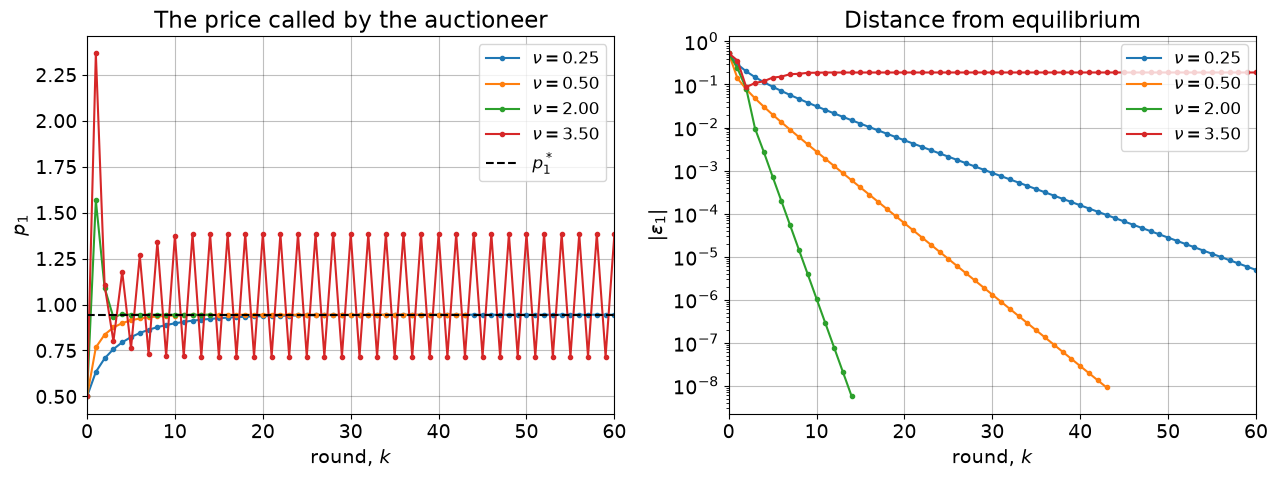

In [22]:
fig = plt.figure(figsize=(13,5))

ax_p = fig.add_subplot(1,2,1)
ax_e = fig.add_subplot(1,2,2)

for i,(nu,path) in enumerate(paths.items()):
    ax_p.plot(path,'-o',ms=3,lw=1.5,color=colors[i],label=fr'$\nu={nu:.2f}$')
    ax_e.plot(np.abs(model.excess_demand(path)[0]),'-o',ms=3,lw=1.5,color=colors[i],label=fr'$\nu={nu:.2f}$')

ax_p.axhline(p1_star,ls='--',lw=1.5,color='black',label='$p_1^*$')
ax_p.set_title('The price called by the auctioneer')
ax_p.set_ylabel('$p_1$')
ax_p.legend(loc='upper right',fontsize=12)

ax_e.set_title('Distance from equilibrium')
ax_e.set_ylabel(r'$|\varepsilon_1|$')
ax_e.set_yscale('log')
ax_e.legend(loc='upper right',fontsize=12)

for ax in fig.axes:
    ax.set_xlabel('round, $k$')
    ax.set_xlim(0,60)

fig.tight_layout()

**The lesson.** With $\nu=3.50$ the auctioneer ends up bouncing between two prices forever: excess demand stops falling and settles at a constant distance from zero (flat line in the right panel, log scale). The model is fine and the code is fine - the *algorithm* is badly tuned.

This is the general picture for hand-written iterative solvers: they contain knobs that have nothing to do with the model, and a bad setting looks like a wrong answer. Two habits protect you:

1. always return (and check) whether the algorithm actually converged,
2. compare against something you trust - here `optimize.root_scalar`, which has no knobs to get wrong.

**Task:** Which step sizes work? Loop over `np.arange(0.01,5.00,0.01)`, record for each $\nu$ whether the algorithm converged and how many prices it called, and find the fastest $\nu$.

In [23]:
# write your code here

In [24]:
# answer
nu_grid = np.arange(0.01,5.00,0.01)

converged_all = np.zeros(nu_grid.size,dtype=bool)
rounds_all = np.zeros(nu_grid.size)

for i,nu in enumerate(nu_grid):
    path,converged = model.tatonnement(p1_guess=0.50,nu=nu)
    converged_all[i] = converged
    rounds_all[i] = path.size

nu_ok = nu_grid[converged_all]
i_best = np.argmin(np.where(converged_all,rounds_all,np.inf))

print(f'converges for nu from {nu_ok.min():.2f} to {nu_ok.max():.2f}')
print(f'fastest: nu = {nu_grid[i_best]:.2f} with {rounds_all[i_best]:.0f} prices')
print(f'nu = {nu_grid[0]:.2f}: converged = {converged_all[0]}, {rounds_all[0]:.0f} prices')
print(f'nu = {nu_grid[-1]:.2f}: converged = {converged_all[-1]}, {rounds_all[-1]:.0f} prices')

converges for nu from 0.06 to 3.09
fastest: nu = 1.57 with 7 prices
nu = 0.01: converged = False, 501 prices
nu = 4.99: converged = False, 501 prices


**Both ends fail, but for different reasons.** A large $\nu$ overshoots and never settles. A very small $\nu$ moves in the right direction every single round - it simply runs out of the `maxiter = 500` rounds we allowed. The printout does not distinguish between the two, which is worth remembering: `converged = False` means *"I did not get there"*, not *"there is nothing to get to"*.

## 7. <a id='toc7_'></a>[Many economies](#toc0_)

### 7.1. <a id='toc7_1_'></a>[Random endowments](#toc0_)

So far we have looked at one economy at a time. Now we draw **many** economies with random endowments,

$$ \omega_1^A,\omega_2^A \sim \mathcal{U}(0,1) $$

and solve every one of them - exactly the pattern from lecture 6 and section 8 of lecture 9: a seeded generator, a loop, and results collected in arrays.

In [25]:
# a. draw the endowments
rng = np.random.default_rng(2026)

N = 200 # number of economies
w1A_draws = rng.uniform(0,1,size=N)
w2A_draws = rng.uniform(0,1,size=N)

# b. allocate memory
p1_all = np.empty(N)
x1A_all = np.empty(N)
x2A_all = np.empty(N)

# c. solve them one by one
for i in range(N):
    model_i = ExchangeEconomy(w1A=w1A_draws[i],w2A=w2A_draws[i])
    sol_i = model_i.solve()
    p1_all[i] = sol_i.p1
    x1A_all[i] = sol_i.x1A
    x2A_all[i] = sol_i.x2A

print(f'the equilibrium price: min = {p1_all.min():.3f}, median = {np.median(p1_all):.3f}, max = {p1_all.max():.3f}')

the equilibrium price: min = 0.536, median = 0.975, max = 1.850


**Nobody is forced to trade.** At the price $p_1^{\ast}$ each of them could always have chosen to keep her endowment, so neither can end up worse off than she started - whatever they happened to be given. That is a *property* the model must have, and as in section 4.4 that makes it a good `assert`. We can now check it in 200 economies at once:

In [26]:
uA_w_all = model.utility_A(w1A_draws,w2A_draws)
uB_w_all = model.utility_B(1-w1A_draws,1-w2A_draws)

uA_all = model.utility_A(x1A_all,x2A_all)
uB_all = model.utility_B(1-x1A_all,1-x2A_all)

assert np.all(uA_all >= uA_w_all-1e-12), 'A is worse off after trading in some economy'
assert np.all(uB_all >= uB_w_all-1e-12), 'B is worse off after trading in some economy'

print('nobody is ever worse off after trading')
print(f'median gain: A {np.median(uA_all/uA_w_all-1)*100:.1f} percent, B {np.median(uB_all/uB_w_all-1)*100:.1f} percent')
print(f'largest gain: A {np.max(uA_all/uA_w_all-1)*100:.0f} percent, B {np.max(uB_all/uB_w_all-1)*100:.0f} percent')

nobody is ever worse off after trading
median gain: A 6.0 percent, B 8.7 percent
largest gain: A 914 percent, B 944 percent


The **median** gain is a few percent while the **largest** is enormous. That is the shape of these things: most random endowments are not very lopsided, but the few that are - somebody owns almost only the good she does not care about - are transformed by being allowed to trade.

### 7.2. <a id='toc7_2_'></a>[The contract curve](#toc0_)

Now plot the 200 economies in one Edgeworth box: a grey square for each endowment, an arrow to where trade takes it, and a coloured dot for the equilibrium.

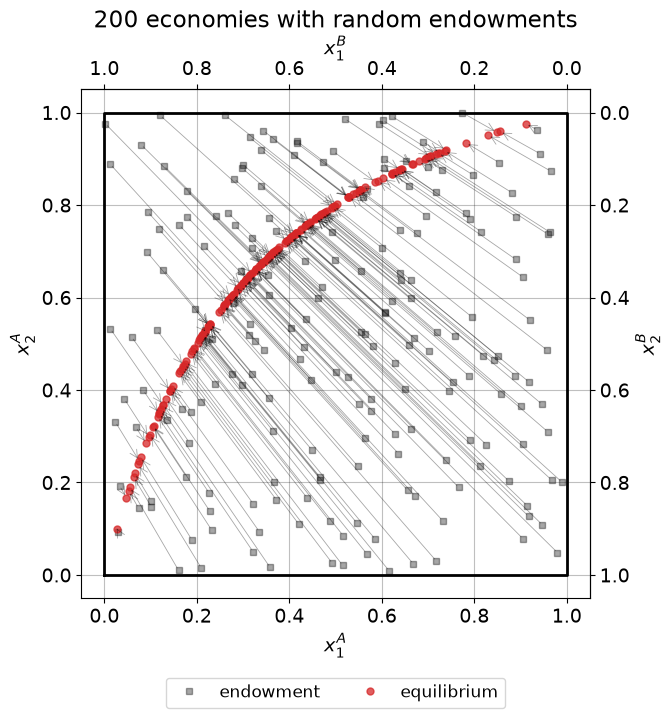

In [27]:
fig,ax = edgeworth_box(figsize=(7.5,7.5))

# a. endowments and equilibria
ax.plot(w1A_draws,w2A_draws,'s',ms=4,color='black',alpha=0.35,label='endowment')
ax.plot(x1A_all,x2A_all,'o',ms=5,color=colors[3],alpha=0.75,label='equilibrium')

# b. an arrow from each endowment to its equilibrium
for i in range(N):
    ax.annotate('',xy=(x1A_all[i],x2A_all[i]),xytext=(w1A_draws[i],w2A_draws[i]),
                arrowprops=dict(arrowstyle='->',lw=0.6,color='black',alpha=0.35))

ax.set_title(f'{N} economies with random endowments')
ax.legend(loc='upper center',bbox_to_anchor=(0.5,-0.14),ncol=2,fontsize=12)
fig.tight_layout()

**The dots do not scatter - they fall on a curve.** Wherever the two start, trade always takes them to the same thin set of allocations. It is called the **contract curve**, and it is the set of points where the two indifference curves touch, so that no further trade could make both better off.

For our utility functions it can be found with pen and paper by setting the slopes of the two indifference curves equal,

$$ x_2^A = \frac{b\,x_1^A}{a + (b-a)\,x_1^A}, \qquad a = \frac{\alpha}{1-\alpha},\quad b = \frac{\beta}{1-\beta} $$

so once again we have an answer to test the numerical one against.

In [28]:
def contract_curve(model,x1A):
    """ A's consumption of good 2 along the contract curve """

    a = model.alpha/(1-model.alpha)
    b = model.beta/(1-model.beta)

    return b*x1A/(a+(b-a)*x1A)

# the 200 equilibria must all lie exactly on it
assert np.allclose(contract_curve(model,x1A_all),x2A_all), 'the equilibria are not on the contract curve'
print('all 200 equilibria lie on the contract curve')

all 200 equilibria lie on the contract curve


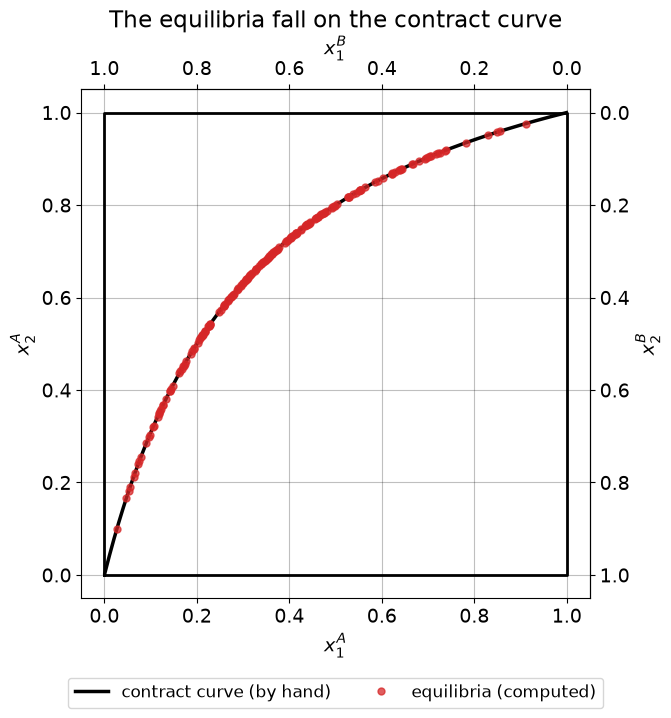

In [29]:
fig,ax = edgeworth_box(figsize=(7.5,7.5))

x1_grid = np.linspace(0.001,0.999,500)
ax.plot(x1_grid,contract_curve(model,x1_grid),lw=2.5,color='black',label='contract curve (by hand)')
ax.plot(x1A_all,x2A_all,'o',ms=5,color=colors[3],alpha=0.75,label='equilibria (computed)')

ax.set_title('The equilibria fall on the contract curve')
ax.legend(loc='upper center',bbox_to_anchor=(0.5,-0.14),ncol=2,fontsize=12)
fig.tight_layout()

Note what happened here: we found the curve **by accident**, by solving a lot of unrelated economies and plotting the answers. Making a figure of your results is not only a way of presenting them - it is a way of *discovering* them.

## 8. <a id='toc8_'></a>[Summary](#toc0_)

Questions? **Socrative room:** PROGECON

**The programming take-aways:**

1. **Models fit naturally in a class.** Parameters are attributes, the equations are methods, the solvers are methods, and the answer is collected in `self.sol`. Several economies can then live side by side - in section 7 we made 200 of them and solved them all in a handful of lines.
2. **Write the methods with plain arithmetic.** Because `demand_A` only uses `+`, `*` and `/`, the very same code that solves a single economy also evaluated a whole grid of 500 prices in one go in section 4.1.
3. **Solve by hand when you can.** The analytical price and the analytical contract curve were the yardstick for everything else in the notebook - including a figure that would have looked convincing even if it had been wrong.
4. **Test with properties, not only with numbers.** The best test in the notebook, $p_1\varepsilon_1+\varepsilon_2=0$, uses no known answer at all - just something that must be true at every price.
5. **Home-made algorithms have knobs.** The auctioneer works fine for $\nu=0.5$ and fails for $\nu=3.5$ *without complaining*. Always return whether the algorithm converged, and check it.
6. **Figures are not always plots of $y$ against $x$.** The Edgeworth box took a helper function of fifteen lines - and then every figure afterwards was three lines.
7. **Solve many random versions of the model.** It turned "here is an equilibrium" into "here is what equilibria look like" - and it drew the contract curve for us for free.